In [7]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

In [8]:
df = pd.read_csv('Data_Cleaned.csv')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 310176 entries, 0 to 310175
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   District           310176 non-null  object        
 1   Local Time         310176 non-null  datetime64[ns]
 2   UTC Time           310176 non-null  object        
 3   City               310176 non-null  object        
 4   Country Code       310176 non-null  object        
 5   Timezone           310176 non-null  object        
 6   AQI                310176 non-null  int64         
 7   CO                 310176 non-null  float64       
 8   NO2                310176 non-null  float64       
 9   O3                 310176 non-null  float64       
 10  PM25               310176 non-null  float64       
 11  SO2                310176 non-null  float64       
 12  Clouds             310176 non-null  float64       
 13  Precipitation      310176 non-null  float64      

In [39]:
df.describe()

,Local Time,AQI,CO,NO2,O3,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
count,310176,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000,310176.000000
mean,2023-07-03 23:45:49.303621120,182.883782,1.870621,50.202709,33.058183,114.583910,40.674092,72.931719,0.216773,1011.021029,78.950254,24.276677,9.094815
min,2022-01-01 07:00:00,0.000000,0.494000,12.340000,0.000000,12.500000,13.830000,0.000000,0.000000,997.500000,40.000000,10.700000,1.300000
25%,2022-10-01 12:45:00,122.000000,0.895000,33.240000,0.100000,44.900000,26.460000,39.000000,0.000000,1005.000000,69.000000,20.600000,5.700000
50%,2023-07-03 18:30:00,169.000000,1.295000,44.895000,8.310000,82.700000,35.290000,100.000000,0.000000,1010.600000,81.000000,25.200000,8.500000
75%,2024-04-03 00:15:00,222.000000,2.163000,61.010000,45.780000,150.200000,49.110000,100.000000,0.100000,1016.500000,91.000000,28.100000,12.100000
max,2025-01-01 06:00:00,500.000000,8.652000,152.170000,246.050000,494.000000,120.160000,100.000000,5.300000,1028.300000,99.000000,35.100000,21.400000
std,NaN,87.701146,1.559461,25.439118,50.939325,97.995373,20.441111,38.046993,0.761341,7.289695,14.327225,5.499704,4.412542


### 3.2. Chỉ số chất lượng không khí (AQI)

 3.2.1. AQI theo giờ của Hà Nội trong suốt cả năm

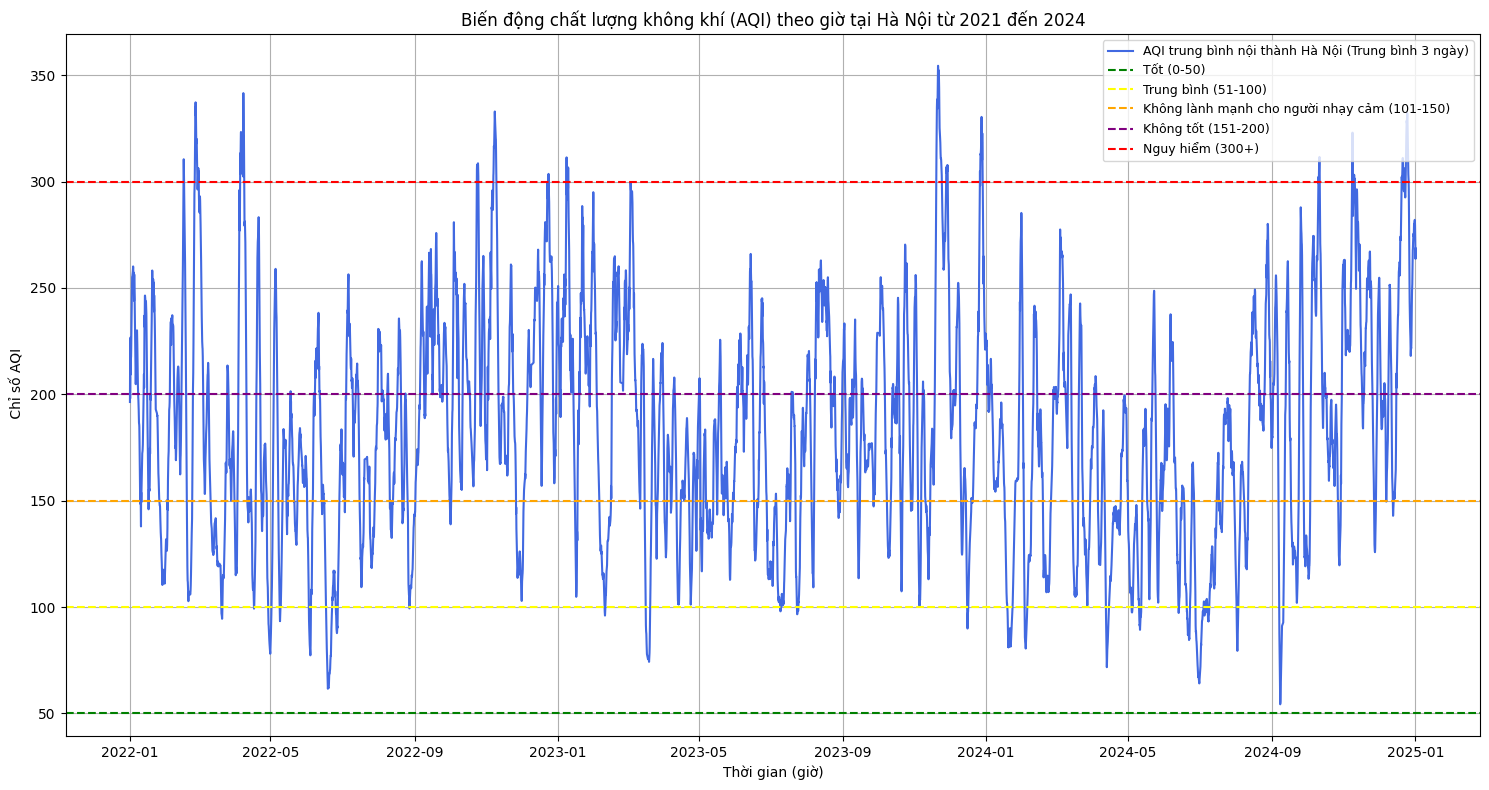

In [45]:

df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
df = df.dropna(subset=["Local Time"]).sort_values("Local Time")


df_mean = (
    df.groupby("Local Time", as_index=False)["AQI"].mean()
    .sort_values("Local Time")
)


df_mean["AQI_rolling"] = (
    df_mean["AQI"].rolling(window=24*3, center=True, min_periods=24).mean()
)
out = df_mean.dropna(subset=["AQI_rolling"])



plt.figure(figsize=(15,8))
plt.plot(out['Local Time'], out['AQI_rolling'], color='royalblue', linewidth=1.5, label='AQI trung bình nội thành Hà Nội (Trung bình 3 ngày)')
plt.axhline(50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(100, color='yellow', linestyle='--', label='Trung bình (51-100)')
plt.axhline(150, color='orange', linestyle='--', label='Không lành mạnh cho người nhạy cảm (101-150)')
plt.axhline(200, color='purple', linestyle='--', label='Không tốt (151-200)')
plt.axhline(300, color='red', linestyle='--', label='Nguy hiểm (300+)')
plt.title("Biến động chất lượng không khí (AQI) theo giờ tại Hà Nội từ 2021 đến 2024")
plt.xlabel("Thời gian (giờ)")
plt.ylabel(" Chỉ số AQI")
plt.legend(loc="upper right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

3.2.2. AQI theo giờ của Hà Nội trong nhiều tháng với mức AQI nguy hiểm

In [56]:
df_city = (
    df.groupby("Local Time", as_index=False)['AQI'].mean().sort_values('Local Time')   
)

# Trung bình AQI theo giờ
df_city["Year"]  = df_city["Local Time"].dt.year
df_city["Month"] = df_city["Local Time"].dt.month

# Tìm các (Year, Month) có ÍT NHẤT một giờ AQI >= 300

monthly_haz = (
    df_city.assign(is_hazardous =(df_city['AQI'] >= 300).astype(int))
    .groupby(['Year', 'Month'])
    .agg(count_hazardous = ('is_hazardous', 'sum'), max_AQI = ('AQI', 'max'), mean_AQI = ('AQI', 'mean'))
    .reset_index()
)

top_months = monthly_haz.sort_values(['count_hazardous', 'max_AQI', 'mean_AQI'], ascending=False).head(3)
top_months


,Year,Month,count_hazardous,max_AQI,mean_AQI
22,2023,11,189,488.0,222.026389
34,2024,11,178,495.0,233.773611
12,2023,1,175,497.0,224.481183


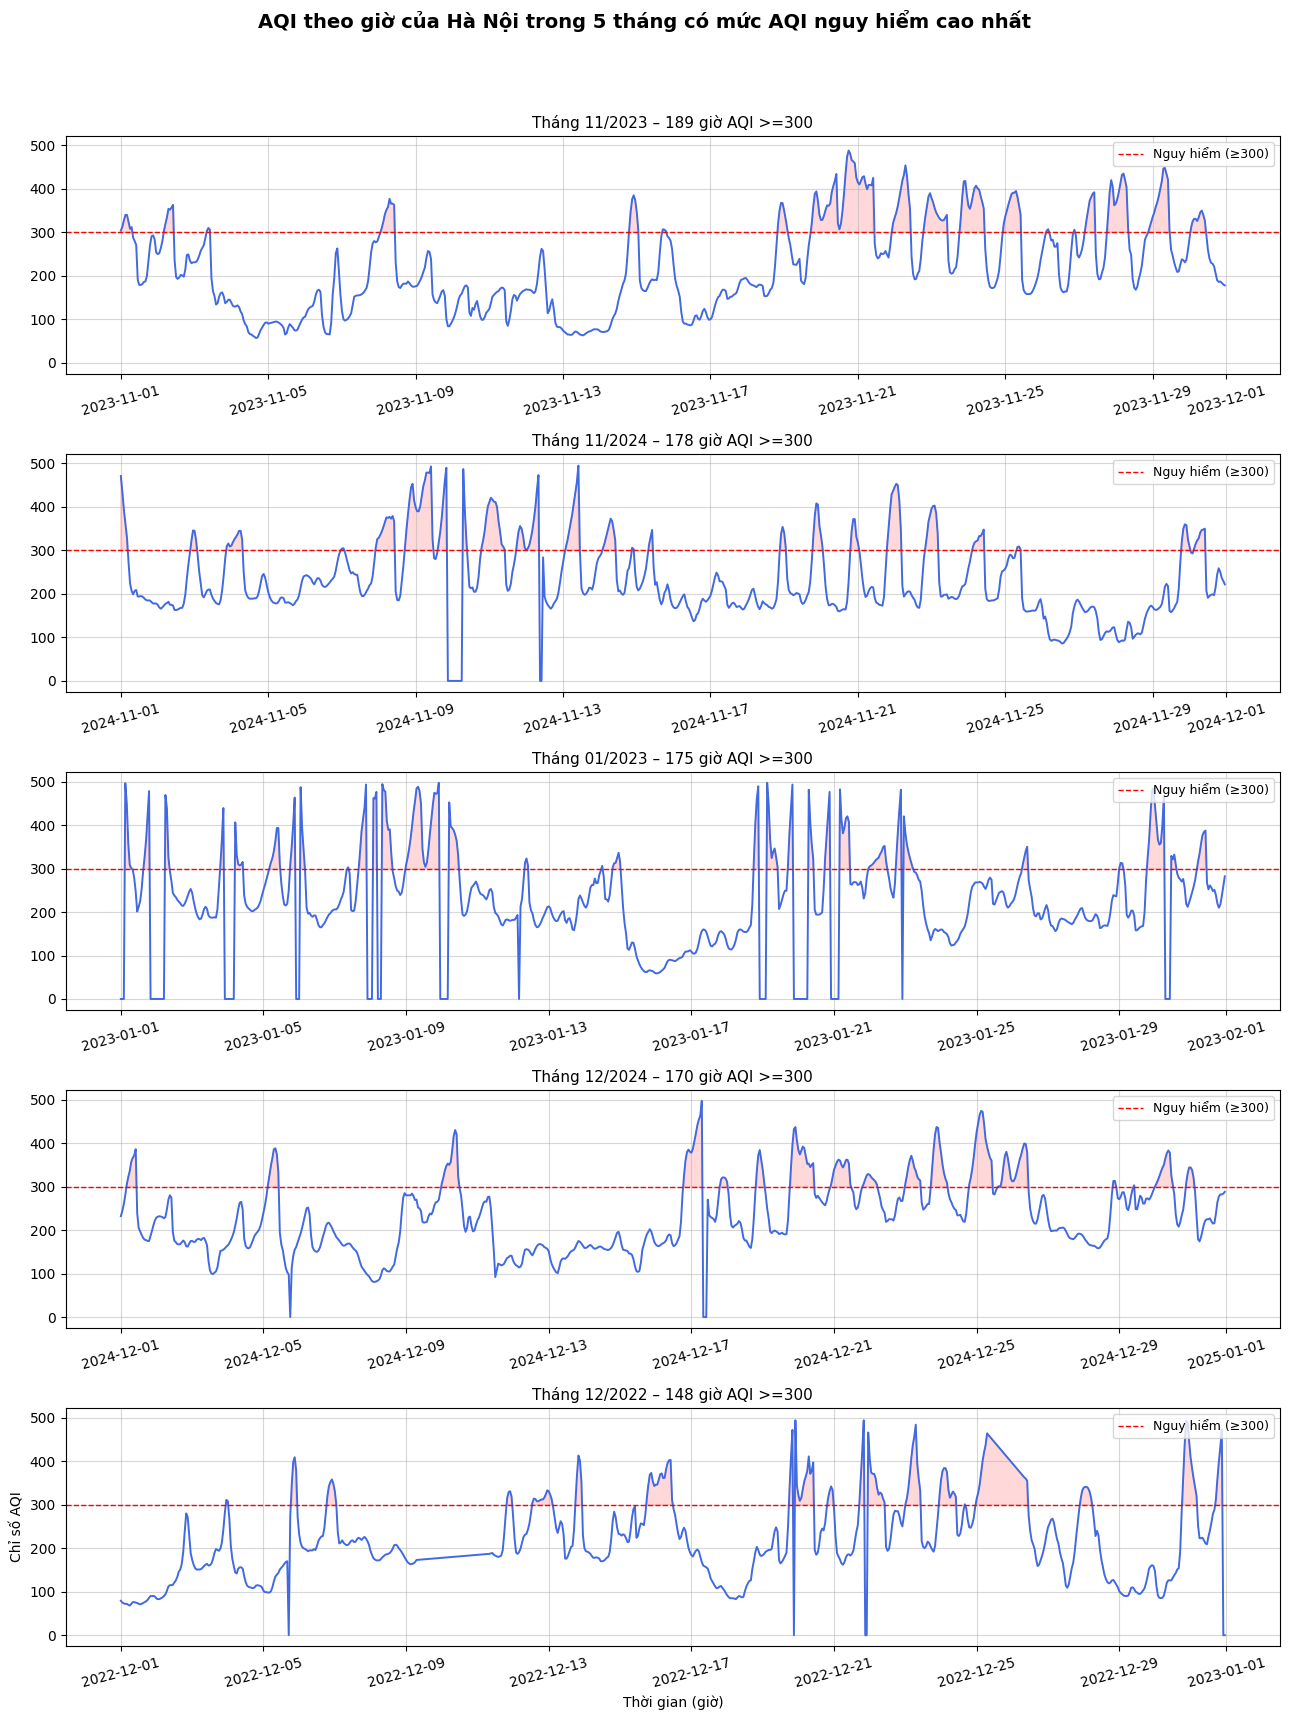

In [55]:
fig, axs = plt.subplots(len(top_months), 1, figsize=(13, 3.5*len(top_months)), sharey=True)

for ax, (_, row) in zip(axs, top_months.iterrows()):
    year, month = int(row["Year"]), int(row["Month"])
    sel = df_city[(df_city["Year"] == year) & (df_city["Month"] == month)]

    # Vẽ đường AQI
    ax.plot(sel["Local Time"], sel["AQI"], color="royalblue", lw=1.4)
    ax.axhline(300, color="red", ls="--", lw=1, label="Nguy hiểm (≥300)")
    
    # Tô màu vùng vượt ngưỡng
    ax.fill_between(sel["Local Time"], sel["AQI"], 300, where=sel["AQI"] >= 300, 
                    color="red", alpha=0.15)
    
    # Tiêu đề phụ từng subplot
    ax.set_title(f"Tháng {month:02d}/{year} – {int(row['count_hazardous'])} giờ AQI >=300", fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.5)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle(f"AQI theo giờ của Hà Nội trong {len(top_months)} tháng có mức AQI nguy hiểm cao nhất", 
             fontsize=14, fontweight="bold")
plt.xlabel("Thời gian (giờ)")
plt.ylabel("Chỉ số AQI")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### 3.3. Pm2.5 Level

3.3.1. Hanoi hourly Pm2.5 level throughout the year

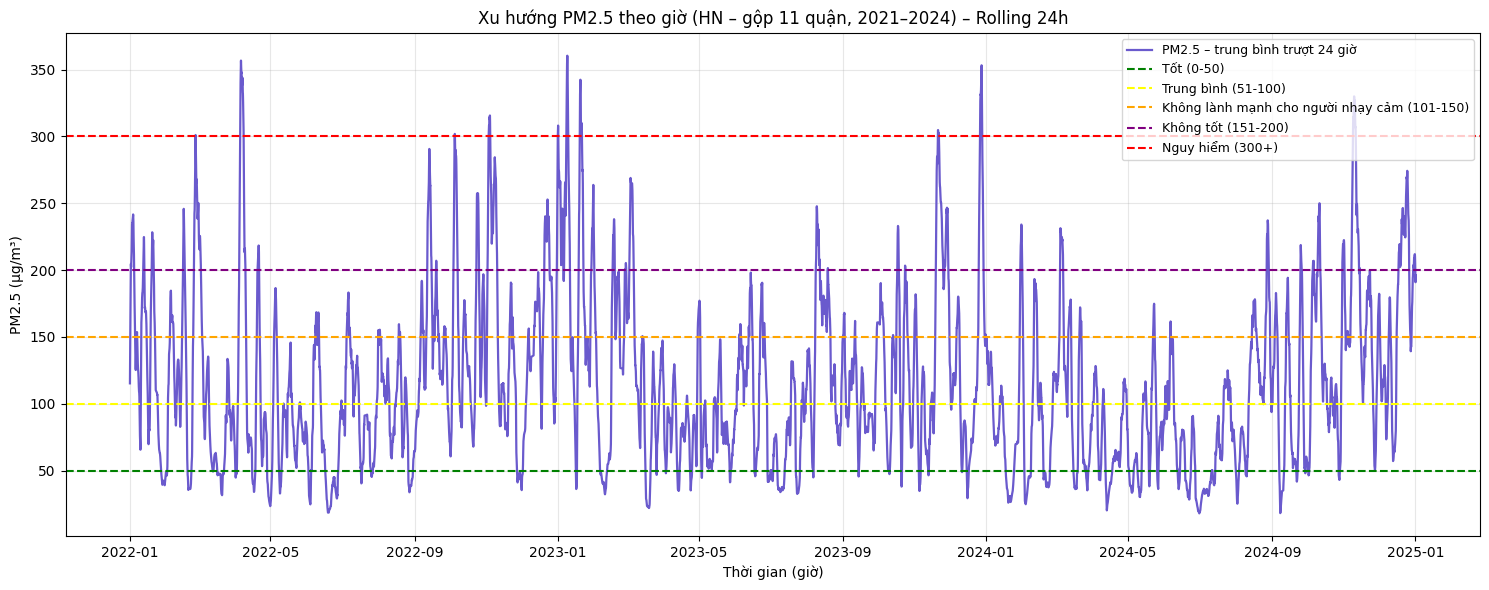

In [61]:
df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
df = df.dropna(subset=["Local Time"]).sort_values("Local Time")


#2) PM2.5 trung bình toàn HN theo giờ (gộp 11 quận)
pmh = (df.groupby("Local Time", as_index=True)["PM25"]
         .mean()
         .sort_index())

# 3) Làm mượt 24 giờ (trung bình trượt 1 ngày)
pmh_roll24 = pmh.rolling(window=24*3, center=True, min_periods=12).mean()

# 4) Vẽ
plt.figure(figsize=(15,6))
plt.plot(pmh_roll24.index, pmh_roll24, color='slateblue', lw=1.6,
         label='PM2.5 – trung bình trượt 24 giờ')

# Ngưỡng US EPA
plt.axhline(50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(100, color='yellow', linestyle='--', label='Trung bình (51-100)')
plt.axhline(150, color='orange', linestyle='--', label='Không lành mạnh cho người nhạy cảm (101-150)')
plt.axhline(200, color='purple', linestyle='--', label='Không tốt (151-200)')
plt.axhline(300, color='red', linestyle='--', label='Nguy hiểm (300+)')

plt.title('Xu hướng PM2.5 theo giờ (HN – gộp 11 quận, 2021–2024) – Rolling 24h')
plt.xlabel('Thời gian (giờ)'); plt.ylabel('PM2.5 (μg/m³)')
plt.legend(loc='upper right', fontsize=9); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()


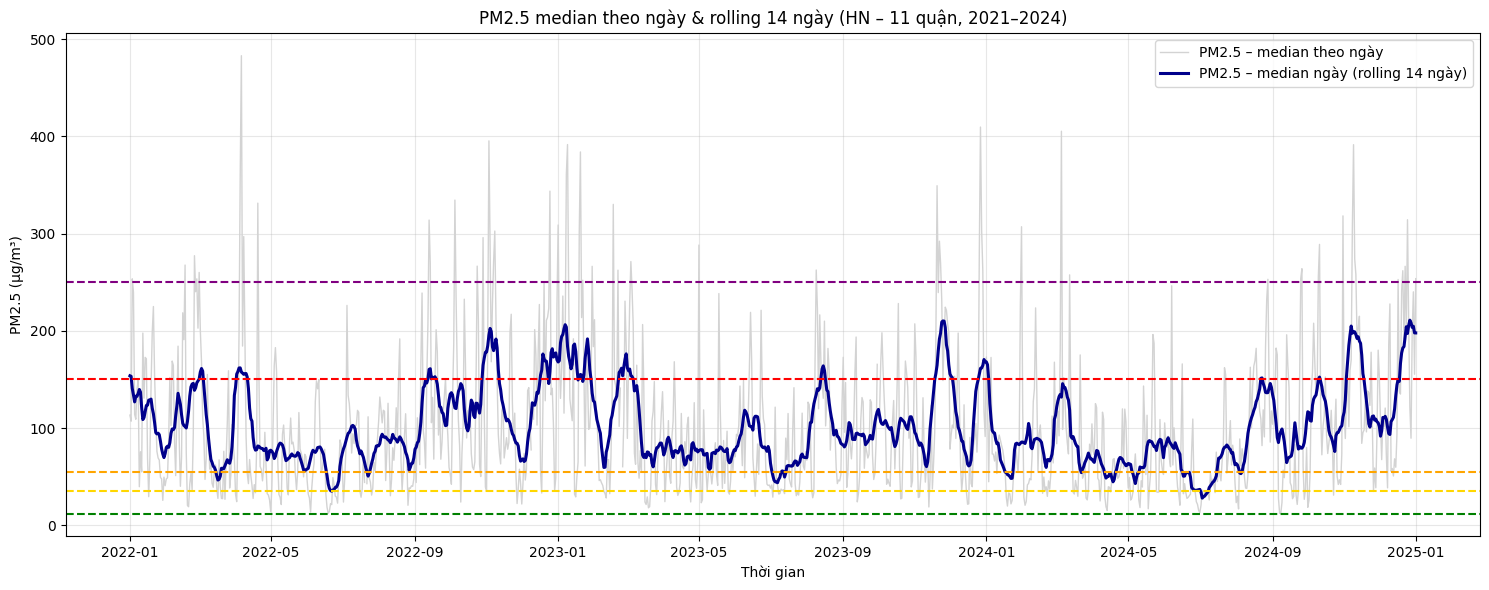

In [62]:
# Resample về từng ngày: median để giảm ảnh hưởng outlier
pm_daily = pmh.resample('D').median()
pm_daily_roll = pm_daily.rolling(window=14, center=True, min_periods=7).mean()

plt.figure(figsize=(15,6))
plt.plot(pm_daily.index, pm_daily, color='lightgray', lw=1, label='PM2.5 – median theo ngày')
plt.plot(pm_daily_roll.index, pm_daily_roll, color='darkblue', lw=2.2,
         label='PM2.5 – median ngày (rolling 14 ngày)')

plt.axhline(12,    color='green',  ls='--');  plt.axhline(35.4, color='gold',   ls='--')
plt.axhline(55.4,  color='orange', ls='--');  plt.axhline(150.4,color='red',    ls='--')
plt.axhline(250.4, color='purple', ls='--')

plt.title('PM2.5 median theo ngày & rolling 14 ngày (HN – 11 quận, 2021–2024)')
plt.xlabel('Thời gian'); plt.ylabel('PM2.5 (μg/m³)')
plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()


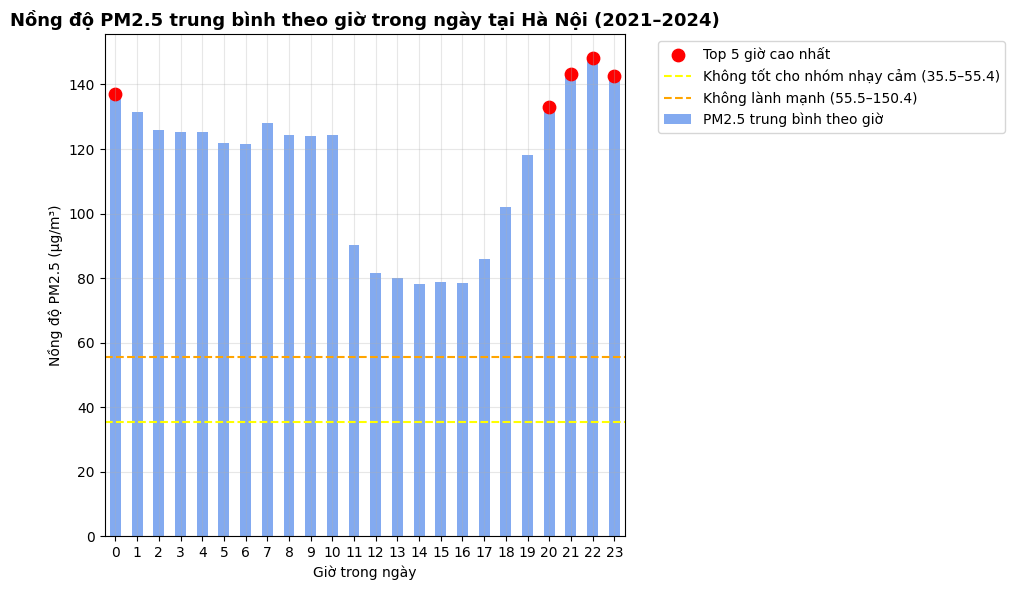

Giờ 22:00 có nồng độ PM2.5 trung bình là 148.13 µg/m³
Giờ 21:00 có nồng độ PM2.5 trung bình là 143.11 µg/m³
Giờ 23:00 có nồng độ PM2.5 trung bình là 142.61 µg/m³
Giờ 00:00 có nồng độ PM2.5 trung bình là 137.10 µg/m³
Giờ 20:00 có nồng độ PM2.5 trung bình là 132.94 µg/m³


In [63]:
# --- Chuẩn hóa thời gian ---
df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
df = df.dropna(subset=["Local Time"]).sort_values("Local Time")
df = df.set_index("Local Time")

# --- Tính trung bình PM2.5 theo từng giờ trong ngày (0h → 23h) ---
hourly_pm25 = df["PM25"].groupby(df.index.hour).mean()

# --- Tìm top 5 khung giờ có PM2.5 cao nhất ---
highest_hours = hourly_pm25.nlargest(5)

# --- Vẽ biểu đồ ---
plt.figure(figsize=(10, 6))
hourly_pm25.plot(kind='bar', color='cornflowerblue', alpha=0.8, label='PM2.5 trung bình theo giờ')

# Đánh dấu các giờ có nồng độ cao nhất
plt.scatter(highest_hours.index, highest_hours.values, color='red', s=80, label='Top 5 giờ cao nhất')

# Đường ngưỡng cảnh báo
plt.axhline(35.5, color='yellow', linestyle='--', label='Không tốt cho nhóm nhạy cảm (35.5–55.4)')
plt.axhline(55.5, color='orange', linestyle='--', label='Không lành mạnh (55.5–150.4)')

# --- Trang trí biểu đồ ---
plt.title("Nồng độ PM2.5 trung bình theo giờ trong ngày tại Hà Nội (2021–2024)", fontsize=13, fontweight='bold')
plt.xlabel("Giờ trong ngày")
plt.ylabel("Nồng độ PM2.5 (μg/m³)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- In ra nồng độ cụ thể ở các giờ cao nhất ---
for hour, value in highest_hours.items():
    print(f"Giờ {hour:02d}:00 có nồng độ PM2.5 trung bình là {value:.2f} µg/m³")
